<a href="https://colab.research.google.com/github/piotrekwisniewski/MachineLearning/blob/main/v1_Meeter_datingApp_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Meeter** 2025 ad campaign
Profiling main customer groups for preparing marketing strategy for targetting new users.


In [41]:
# packages import
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt


In [42]:
# initial settings

# dropping warning messages
import warnings
warnings.filterwarnings('ignore')

# # Google Drive mount
# from google.colab import drive
# drive.mount('/content/drive')


In [43]:
# Pandas settings
# display settings
pd.options.display.max_columns = None
pd.options.display.max_rows = 40

pd.options.mode.copy_on_write = True

## 1. Data exploration

### 1.1. Dataset loading

In [44]:
data_raw = pd.read_csv('https://drive.google.com/uc?id=1wmtMusQYWSMK7tVspqUUdrDBCM80BRCT', encoding='ISO-8859-1')
data_raw.shape

(8378, 195)

### 1.2. Data cleansing

In [45]:
# data_raw cleansing

# # diplaying empty values
# data_raw_na = data_raw.isna().sum()
# data_raw_na[data_raw_na > 0].sort_values(ascending=False)


In [46]:
col_all = data_raw.columns.to_list()
# col_all

In [47]:
# dissmissing unnecessary columns
data = data_raw[['iid',
 'gender',
 'wave',
 'age',
 'field_cd',  #field coded
 'race',  # race o participant
 'imprace',  # how important is the same race
 'imprelig',  # how important is the same religion
 'goal',  # What is your primary goal in participating in this event?
# activities participant are interested in:
 'sports',
 'tvsports',
 'exercise',
 'dining',
 'museums',
 'art',
 'hiking',
 'gaming',
 'clubbing',
 'reading',
 'tv',
 'theater',
 'movies',
 'concerts',
 'music',
 'shopping',
 'yoga',
 # What are you looking for in opposite sex
 'attr1_1',
 'sinc1_1',
 'intel1_1',
 'fun1_1',
 'amb1_1',
 'shar1_1',
# How do you think you measure up?
 'attr3_1',
 'sinc3_1',
 'fun3_1',
 'intel3_1',
 'amb3_1']].copy()

In [48]:
# setting target dataframe for further purposes
df = data.copy()
df.drop_duplicates(subset=['iid'], inplace=True)
df= df.set_index('iid')
df = df.reset_index()

### 1.3. Missing data treatment

In [49]:
# # diplaying empty values
# df = df.isna().sum()
# df[df > 0].sort_values(ascending=False)

In [50]:
# df.age.describe()

In [51]:
# missing data treatment
df['age'] = df['age'].fillna(df['age'].median())

# other missing values completing using SimpleImputer
from sklearn.impute import SimpleImputer

all_cols = df.select_dtypes(include=['number', 'object']).columns
simpimp = SimpleImputer(strategy='most_frequent')

# Apply imputer to columns in dataframe
df[all_cols] = simpimp.fit_transform(df[all_cols])

df['iid'] = df['iid'].astype(int)  # back to int type

In [52]:
# # diplaying empty values (for verification cases- correct if '0')
# data_nulls = df.isna().sum()
# data_nulls[data_nulls > 0].sort_values(ascending=False)

### 1.4. EDA (exploratory data analysis) with SwitViz

In [53]:
# !pip install sweetviz -qq

In [54]:
# import sweetviz as sv
## basic report
# basic_report = sv.analyze(df, pairwise_analysis="off")
# basic_report.show_html(filepath='basic_report.html',  layout='vertical')
# basic_report.show_notebook()

In [55]:
## report by gender
# df_gend = df.copy()
# df_gend['gender'] = df_gend['gender'].map({0:'Female', 1:'Male'})

# gender_report = sv.compare_intra(df_gend,
#                                 df_gend["gender"] == "Male",
#                                 ["Male", "Female"],
#                                 pairwise_analysis="off")
# gender_report.show_notebook()

In [56]:
# waves 6-9 check
df['sum_of_features'] = df.loc[:,['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']].sum(axis=1)
# df.sort_values(by='sum_of_features', ascending= False)
# df['sum_of_features'].value_counts().sort_index()

In [57]:
# drop indexes that have sum of features >101
df = df[df['sum_of_features'] <= 101]
df = df.reset_index()
df.drop(columns='index', inplace=True)

In [58]:
# self esteem column (sum of own attributes rate)
df['self_esteem'] = df.loc[:,['attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1']].sum(axis=1)
# df.sort_values(by='sum_of_features', ascending= False)
# df['self_esteem'].value_counts().sort_index()

### 1.5. Features mapping

In [59]:
# categorical columns decoding

gender_mapper = {0:'Female', 1:'Male'}

field_cd_mapper = {1: 'Law',
                   2: 'Math',
                   3: 'Social Science, Psychologist',
                   4: 'Medical Science, Pharmaceuticals, and Bio Tech',
                   5: 'Engineering',
                   6: 'English/Creative Writing/ Journalism',
                   7: 'History/Religion/Philosophy',
                   8: 'Business/Econ/Finance',
                   9: 'Education, Academia',
                   10:'Biological Sciences/Chemistry/Physics',
                   11:'Social Work',
                   12:'Undergrad/undecided',
                   13:'Political Science/International Affairs',
                   14:'Film',
                   15:'Fine Arts/Arts Administration',
                   16:'Languages',
                   17:'Architecture',
                   18:'Other'}

goal_mapper = {1: 'Seemed like a fun night out',
               2: 'To meet new people',
               3: 'To get a date',
               4: 'Looking for a serious relationship',
               5: 'To say I did it',
               6: 'Other'}

goal_mapper_narrowed = {1: 'Fun',
               2: 'Fun',
               3: 'Looking for a relationship',
               4: 'Looking for a relationship',
               5: 'Fun',
               6: 'Other'}


race_mapper = {1: 'Black/African American',
               2: 'European/Caucasian-American',
               3: 'Latino/Hispanic American',
               4: 'Asian/Pacific Islander/Asian-American',
               5: 'Native American',
               6: 'Other'}

df['gender_labelled'] = df['gender'].fillna(2).map(gender_mapper)
df['field'] = df['field_cd'].fillna(18).map(field_cd_mapper)
df['goal_labelled'] = df['goal'].fillna(6).map(goal_mapper)
df['goal_labelled_narrowed'] = df['goal'].fillna(6).map(goal_mapper_narrowed)
df['race_labelled'] = df['race'].fillna(6).map(race_mapper)

In [60]:
# field grouping- new columns for each field

field_mapping = {
    'Engineering/Math/Science': ['Math', 'Medical Science, Pharmaceuticals, and Bio Tech', 'Engineering', 'Biological Sciences/Chemistry/Physics'],
    'Business': ['Business/Econ/Finance', 'Political Science/International Affairs'],
    'Humanities/Social/Education': ['Law',  'Social Science, Psychologist', 'English/Creative Writing/ Journalism ', 'History/Religion/Philosophy ', 'Education, Academia', 'Social Work', 'Languages'],
    'Design/Arts/Other': ['Undergrad/undecided', 'Film', 'Fine Arts/Arts Administration', 'Architecture', 'Other' ]
}


def categorize_field(value):
    for key, fields in field_mapping.items():
        if value in fields:
            return key
    return None

# new columns
df['Field_1'] = df['field'].apply(lambda x: 1 if categorize_field(x) == 'Engineering/Math/Science' else 0)
df['Field_2'] = df['field'].apply(lambda x: 1 if categorize_field(x) == 'Business' else 0)
df['Field_3'] = df['field'].apply(lambda x: 1 if categorize_field(x) == 'Humanities/Social/Education' else 0)
df['Field_4'] = df['field'].apply(lambda x: 1 if categorize_field(x) == 'Design/Arts/Other' else 0)

In [61]:
# field group- one column with all groups

field_group_mapping = {'Engineering/Math/Science': [2, 4, 5, 10],
                       'Business': [8, 13],
                       'Humanities/Social/Education': [1, 3, 6, 7, 9, 11, 16],
                       'Design/Arts/Other': [12, 14, 15, 17, 18]}

def assign_group(value):
    for group, fields in field_mapping.items():
        if value in fields:
            return group

df['field_group'] = df['field'].apply(assign_group)

In [62]:
# activieties groupping

activities_mapping = {
    'Activ_1': ['sports', 'exercise', 'hiking', 'yoga'],  # sports
    'Activ_2': ['museums', 'art', 'reading', 'theater', 'music'],  # culture
    'Activ_3': ['dining', 'clubbing', 'concerts'],  # going_out
    'Activ_4': ['tvsports', 'gaming', 'tv', 'movies', 'shopping']  # chilling
}

for new_col, cols in activities_mapping.items():
    df[new_col] = df[cols].sum(axis=1)


In [63]:
df.columns

Index(['iid', 'gender', 'wave', 'age', 'field_cd', 'race', 'imprace',
       'imprelig', 'goal', 'sports', 'tvsports', 'exercise', 'dining',
       'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv',
       'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'attr1_1',
       'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1', 'attr3_1',
       'sinc3_1', 'fun3_1', 'intel3_1', 'amb3_1', 'sum_of_features',
       'self_esteem', 'gender_labelled', 'field', 'goal_labelled',
       'goal_labelled_narrowed', 'race_labelled', 'Field_1', 'Field_2',
       'Field_3', 'Field_4', 'field_group', 'Activ_1', 'Activ_2', 'Activ_3',
       'Activ_4'],
      dtype='object')

### 1.5. Race insights

In [64]:
fig = px.histogram(df, x="race_labelled", color="goal_labelled", facet_row='gender_labelled', barmode="group" )

fig.update_layout(title="Goal for dating",
                  xaxis_title="Race",
                  yaxis_title="count")

fig.show()

Data vizu

## 2. Clustering

### 2.1. K-means clustering algorithm

In [65]:
# perform k-means clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# scale the data
scaler = StandardScaler()
cluster_feats = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1', 'imprace', 'imprelig', 'self_esteem', 'Activ_1', 'Activ_2',
       'Activ_3', 'Activ_4']
df_scaled = scaler.fit_transform(df.loc[:, cluster_feats])
df_scaled

array([[-0.59080719,  0.3738426 , -0.02359368, ..., -2.47719254,
         0.8354986 ,  0.37938944],
       [ 1.77479878, -1.71725479,  0.70782663, ...,  0.6672361 ,
         1.06954147, -1.13311318],
       [ 0.98626346, -1.02022233,  2.17066725, ..., -0.97333537,
        -0.10067285,  1.06689063],
       ...,
       [ 0.59199579, -1.99606777,  1.43924694, ..., -0.01633535,
         0.13337001, -0.72061246],
       [ 1.38053112,  0.3738426 , -0.02359368, ..., -0.5631925 ,
        -0.10067285, -1.40811365],
       [ 3.74613709, -2.41428725, -0.755014  , ...,  1.21409325,
         2.00571292, -0.72061246]])

## Elbow method & scree plot

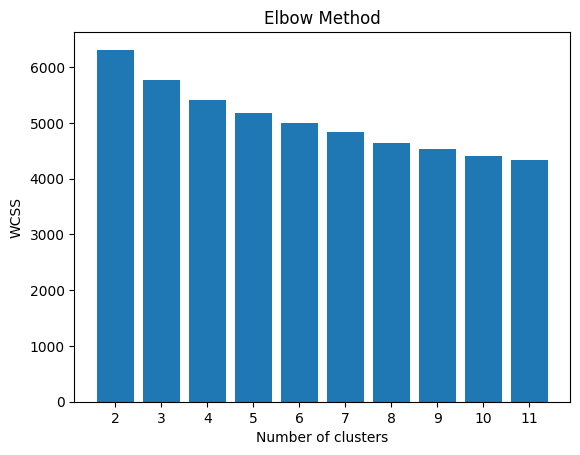

In [66]:
# calculate WCSS for different k values
wcss = []
for i in range(2, len(cluster_feats)-1):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# plot the elbow curve
plt.bar([str(i) for i in range(2,len(cluster_feats)-1)], wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

### kmeans

In [67]:
# perform k-means clustering for 7 clusters
kmeans = KMeans(n_clusters=7, init='k-means++', max_iter=300, n_init=10, random_state=42)
labels = kmeans.fit_predict(df_scaled)

In [68]:
#Vector with cluster assignments - each observation belongs to one cluster
labels

array([6, 0, 0, 1, 0, 6, 1, 1, 1, 4, 6, 4, 3, 4, 1, 0, 6, 2, 5, 5, 2, 6,
       3, 1, 3, 6, 1, 1, 3, 1, 3, 0, 3, 0, 3, 2, 3, 5, 3, 3, 4, 6, 6, 2,
       6, 6, 0, 1, 3, 0, 2, 5, 6, 1, 2, 3, 1, 1, 2, 1, 1, 0, 3, 3, 6, 6,
       0, 1, 5, 3, 4, 1, 1, 0, 1, 6, 2, 2, 2, 1, 6, 6, 2, 6, 3, 3, 1, 6,
       0, 1, 1, 2, 2, 3, 4, 4, 1, 2, 5, 0, 3, 3, 6, 0, 6, 0, 0, 2, 6, 1,
       3, 6, 2, 1, 3, 5, 0, 3, 5, 5, 5, 1, 3, 6, 4, 6, 2, 3, 3, 2, 1, 1,
       2, 3, 2, 3, 1, 1, 1, 2, 2, 1, 3, 1, 2, 1, 1, 1, 2, 1, 1, 1, 6, 3,
       2, 3, 1, 6, 6, 2, 4, 6, 6, 1, 6, 1, 3, 3, 1, 2, 3, 2, 3, 1, 1, 3,
       2, 1, 1, 3, 6, 2, 1, 1, 6, 6, 2, 1, 3, 2, 1, 1, 3, 1, 1, 3, 2, 2,
       3, 2, 1, 2, 1, 2, 2, 3, 3, 3, 2, 1, 2, 2, 2, 1, 1, 2, 2, 3, 2, 3,
       1, 3, 6, 2, 6, 1, 2, 1, 2, 1, 1, 2, 1, 2, 3, 5, 1, 6, 2, 0, 6, 6,
       6, 2, 1, 1, 1, 1, 3, 6, 6, 3, 2, 1, 2, 1, 6, 2, 6, 0, 6, 6, 6, 0,
       6, 3, 3, 6, 1, 1, 0, 4, 1, 0, 0, 6, 1, 5, 6, 1, 2, 6, 6, 6, 0, 2,
       1, 3, 0, 2, 3, 3, 1, 1, 1, 3, 5, 1, 2, 3, 3,

In [69]:
df['cluster'] = labels

#### 2.3.1. Clusters bar comparison

#### 2.2. Predicions

In this section you can verify which cluster is assigned to somebody who characterize by vectorized set of features that he/she is looking in other people.

In [70]:
# Check what's the score for someone mainly looking for people:
# vec = [0, 0, 70, 10, 10, 10, 2, 2, 90] # <change here>

# vec_scaled = scaler.transform(np.array(vec).reshape(1, len(vec)))
# print(f'Selected cluster for vector {vec} is {kmeans.predict(vec_scaled)[0]}')

### 2.3. Clusters vizualisations

In [71]:
# check main clusters
cluster_counts = df['cluster'].value_counts()

fig = px.pie(values=cluster_counts,
             names=cluster_counts.index,
             title="Cluster sizes")

fig.update_layout(
    width=400,  # in pixels
    height=400  # in pixels
)
fig.show()

In [72]:
# subset for 3 chosen clusters
df['cluster_int'] = df['cluster'].astype(int)

df_filtered = df[df['cluster'].isin([0, 3, 5])]

In [73]:
# Plot: Clusters by field group
fig = px.histogram(df_filtered, x="field_group", color="gender_labelled", facet_col='cluster', barmode="overlay" )
fig.show()

In [74]:
# polar plot scaled
df_viz = pd.DataFrame(df_scaled,
                      columns = df.loc[:, cluster_feats].columns)

df_viz['labels'] = labels
df_viz_ = df_viz.groupby('labels').mean().reset_index().melt(id_vars = ['labels'])

fig = px.line_polar(df_viz_,
                    r = "value",
                    theta = "variable",
                    line_close = True,
                    color = "labels",
                    color_discrete_sequence = px.colors.sequential.Plasma_r)

fig.update_layout(polar = dict(
    radialaxis = dict(
      visible = True,
      range = [-2, 3]
    )),
  showlegend = True
)
fig.update_layout(
    width=600,  # in pixels
    height=600  # in pixels
)

fig.show()

In [75]:
# Activities cluster == 0
df_cluster_0 = df_filtered[df_filtered['cluster'] == 0]

# Summing values in activity columns
df_cluster_0['Activ_1_sum'] = df_cluster_0[['sports', 'exercise', 'hiking', 'yoga']].sum(axis=1)
df_cluster_0['Activ_2_sum'] = df_cluster_0[['museums', 'art', 'reading', 'theater', 'music']].sum(axis=1)
df_cluster_0['Activ_3_sum'] = df_cluster_0[['dining', 'clubbing', 'concerts']].sum(axis=1)
df_cluster_0['Activ_4_sum'] = df_cluster_0[['tvsports', 'gaming', 'tv', 'movies', 'shopping']].sum(axis=1)

# Subset of the summed values
df_sums = df_cluster_0[['Activ_1_sum', 'Activ_2_sum', 'Activ_3_sum', 'Activ_4_sum']]

# Creating a histogram with the sums
fig = px.histogram(df_sums,
                   title="Activities in Cluster 0",
                   labels={"value": "Sum of Activity Values", "variable": "Type of Activity"},
                   barmode="overlay",  # Overlapping bars
                   color_discrete_sequence=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"],  # Colors for activities
                   histnorm="probability density"  # Normalizing to probability density
                  )

# Adjusting the plot appearance
fig.update_layout(
    xaxis_title="Sum of Activity Values",
    yaxis_title="Probability Density",
    title_font_size=20,
    font=dict(family="Arial, sans-serif", size=12),
    legend_title="Type of Activity",
    showlegend=True
)

# Display the plot
fig.show()


In [76]:
# Activities cluster == 3
df_cluster_3 = df_filtered[df_filtered['cluster'] == 3]

# Summing values in activity columns
df_cluster_3['Activ_1_sum'] = df_cluster_3[['sports', 'exercise', 'hiking', 'yoga']].sum(axis=1)
df_cluster_3['Activ_2_sum'] = df_cluster_3[['museums', 'art', 'reading', 'theater', 'music']].sum(axis=1)
df_cluster_3['Activ_3_sum'] = df_cluster_3[['dining', 'clubbing', 'concerts']].sum(axis=1)
df_cluster_3['Activ_4_sum'] = df_cluster_3[['tvsports', 'gaming', 'tv', 'movies', 'shopping']].sum(axis=1)

# Subset of the summed values
df_sums_3 = df_cluster_3[['Activ_1_sum', 'Activ_2_sum', 'Activ_3_sum', 'Activ_4_sum']]

# Creating a histogram with the sums
fig_3 = px.histogram(df_sums_3,
                     title="Activities in Cluster 3",
                     labels={"value": "Sum of Activity Values", "variable": "Type of Activity"},
                     barmode="overlay",  # Overlapping bars
                     color_discrete_sequence=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"],  # Colors for activities
                     histnorm="probability density"  # Normalizing to probability density
                    )

# Adjusting the plot appearance
fig_3.update_layout(
    xaxis_title="Sum of Activity Values",
    yaxis_title="Probability Density",
    title_font_size=20,
    font=dict(family="Arial, sans-serif", size=12),
    legend_title="Type of Activity",
    showlegend=True
)

# Display the plot
fig_3.show()


In [77]:
# Activities cluster == 5
df_cluster_5 = df_filtered[df_filtered['cluster'] == 5]

# Summing values in activity columns
df_cluster_5['Activ_1_sum'] = df_cluster_5[['sports', 'exercise', 'hiking', 'yoga']].sum(axis=1)
df_cluster_5['Activ_2_sum'] = df_cluster_5[['museums', 'art', 'reading', 'theater', 'music']].sum(axis=1)
df_cluster_5['Activ_3_sum'] = df_cluster_5[['dining', 'clubbing', 'concerts']].sum(axis=1)
df_cluster_5['Activ_4_sum'] = df_cluster_5[['tvsports', 'gaming', 'tv', 'movies', 'shopping']].sum(axis=1)

# Subset of the summed values
df_sums_5 = df_cluster_5[['Activ_1_sum', 'Activ_2_sum', 'Activ_3_sum', 'Activ_4_sum']]

# Creating a histogram with the sums
fig_5 = px.histogram(df_sums_5,
                     title="Activities in Cluster 5",
                     labels={"value": "Sum of Activity Values", "variable": "Type of Activity"},
                     barmode="overlay",  # Overlapping bars
                     color_discrete_sequence=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"],  # Colors for activities
                     histnorm="probability density"  # Normalizing to probability density
                    )

# Adjusting the plot appearance
fig_5.update_layout(
    xaxis_title="Sum of Activity Values",
    yaxis_title="Probability Density",
    title_font_size=20,
    font=dict(family="Arial, sans-serif", size=12),
    legend_title="Type of Activity",
    showlegend=True
)

# Display the plot
fig_5.show()


## 2.4. PCA

### 2d

In [79]:
from sklearn.decomposition import PCA

# perform PCA
pca = PCA(n_components=2)
pca_df = pca.fit_transform(df_scaled)
pca_df

array([[-0.02269166, -0.83739869],
       [ 2.23215074,  0.57485021],
       [ 0.46481962,  1.36447252],
       ...,
       [ 1.65088628,  0.17305962],
       [ 3.30601751, -0.45580492],
       [ 3.08848529,  3.43910854]])

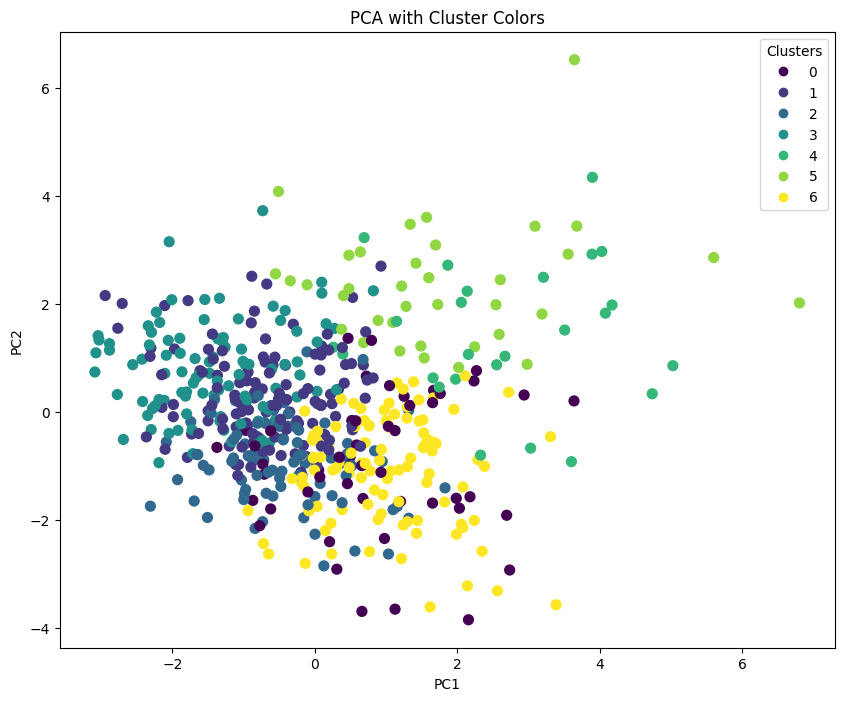

In [80]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_df = pca.fit_transform(df_scaled)

y = df['cluster']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_df[:, 0], pca_df[:, 1], c=y, cmap='viridis', s=50)
plt.title('PCA with Cluster Colors')
plt.xlabel('PC1')
plt.ylabel('PC2')

# add legend
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [81]:
#you can check that sum of squred loading scores sums up to 1 (as eigenvector is normalized)
print("PC1", sum([x**2 for x in pca.components_[0]]))
print("PC2", sum([x**2 for x in pca.components_[1]]))

PC1 1.0000000000000009
PC2 0.9999999999999987


### 3d

In [82]:
# Perform PCA 3D

pca = PCA(n_components=3) #We can generate more than 2 components (up to the #variables in our dataset)
pca_df3 = pca.fit_transform(df_scaled)
pca_df3 #Transformed dataset

array([[-0.02269166, -0.83739869,  0.11522973],
       [ 2.23215074,  0.57485021, -0.25181189],
       [ 0.46481962,  1.36447252,  1.68762887],
       ...,
       [ 1.65088628,  0.17305962,  1.02380489],
       [ 3.30601751, -0.45580492, -0.88521316],
       [ 3.08848529,  3.43910854, -1.43446384]])

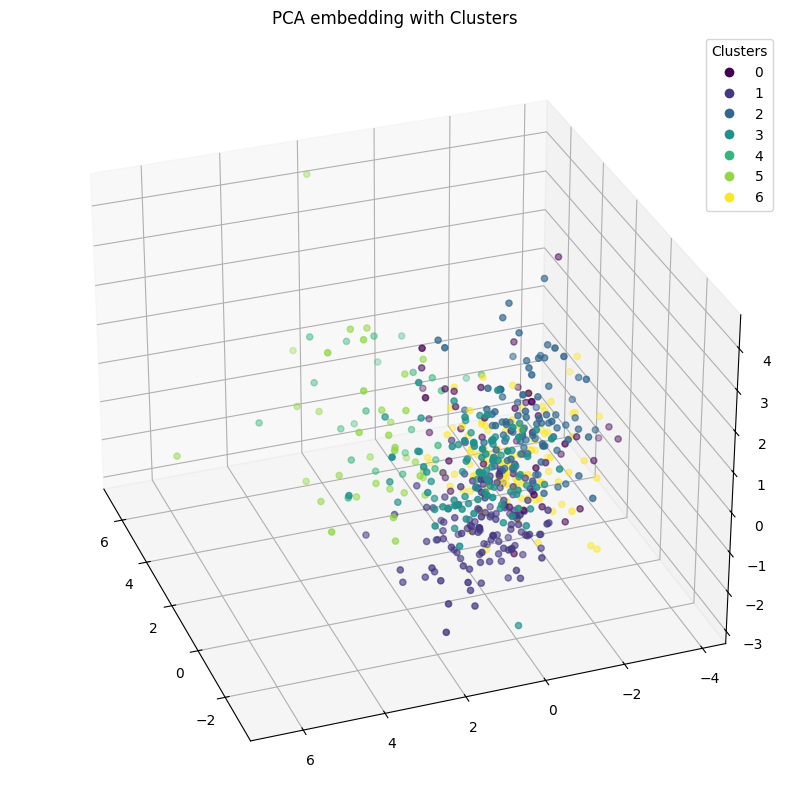

In [84]:
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection="3d")

y = df['cluster']

# Creating plot
scatter = ax.scatter3D(pca_df3[:, 0],
                        pca_df3[:, 1],
                        pca_df3[:, 2],
                        c=y,
                        cmap='viridis')

plt.title("PCA embedding with Clusters")
ax.view_init(30, 160)

# Dodajemy legendę
plt.legend(*scatter.legend_elements(), title="Clusters")

# Show plot
plt.show()